# DTGS185. Figure 1e: Simulating Giant Unilamellar Vesicles (GUVs)

This notebook simulates a two-channel fluorescence image of phase-separated giant unilamellar vesicles (GUVs) with DeepTrack2, reproducing the GUV panel of Figure 1e. Each vesicle is a thin circular membrane shell partitioned into a majority Lo (liquid- ordered) phase and a minority, patch-forming Ld (liquid-disordered) phase, imaged in two channels and rendered alongside its ground-truth phase mask.


In [1]:
# !pip install deeptrack  # Uncomment if running on Colab/Kaggle.


In [2]:
import random

import numpy as np
from matplotlib import pyplot as plt
from scipy import ndimage

import deeptrack as dt
from deeptrack.optical.scatterers import VolumeScatterer


def seed_everything(seed: int = 123) -> None:
    random.seed(seed)
    np.random.seed(seed)


SEED = 234
seed_everything(SEED)


/Users/cmanzo/Documents/GitHub/Environments/deeptrack_fixes/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/cmanzo/Documents/GitHub/Environments/deeptrack_fixes/lib/python3.12/site-packages/torch/jit/_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(
/Users/cmanzo/Documents/GitHub/Environments/deeptrack_fixes/lib/python3.12/site-packages/torch/jit/_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


## 1. Modeling Phase-Separated Vesicles

Each vesicle's membrane is a thin ring, partitioned into Lo and Ld domains at fixed angular positions. The partition is generated as an exact, hard-edged 0/1 array: this keeps the continuous array's centroid and any threshold of it identical, which is what lets a single position-correction term (below) place both the rendered image (`dt.Fluorescence`, which centroids the continuous array) and the ground-truth mask (`dt.SampleToMasks`, which centroids a thresholded copy) at the same true geometric center. Softening the boundary for visual realism belongs downstream, in the optics/blur pipeline -- not in this generative pattern.


In [3]:
RESOLUTION = 1e-7
SAMPLE_VOXEL_SIZE = np.array([1e-7, 1e-7, 1e-7])


def _ring_pattern(radius, thickness, voxel_size, centers, shares, ld_fraction, phase):
    """Pure function building the ring + Lo/Ld domain partition array."""
    radius = float(np.asarray(radius).reshape(-1)[0])
    thickness = float(np.asarray(thickness).reshape(-1)[0])
    voxel_size = np.asarray(voxel_size)
    centers = np.asarray(centers, dtype=float).reshape(-1)
    shares = np.asarray(shares, dtype=float).reshape(-1)

    rad_ceil = int(np.ceil((radius + thickness) / np.min(voxel_size[:2]))) + 2
    x = np.arange(-rad_ceil, rad_ceil) * voxel_size[0]
    y = np.arange(-rad_ceil, rad_ceil) * voxel_size[1]
    z = np.arange(-1, 1) * voxel_size[2]
    Y, X, Z = np.meshgrid(y, x, z, indexing="xy")

    R = np.sqrt(X**2 + Y**2)
    THETA = np.arctan2(Y, X)
    ring_mask = (R >= radius - thickness / 2) & (R <= radius + thickness / 2)

    half_widths = np.pi * ld_fraction * shares
    delta = THETA[..., None] - centers
    delta = (delta + np.pi) % (2 * np.pi) - np.pi
    dist = np.abs(delta)
    is_ld = np.any(dist <= half_widths, axis=-1)  # hard, exact geometric partition

    weight = is_ld if phase == "ld" else ~is_ld
    array = (ring_mask * weight).astype(np.float32)
    return array, rad_ceil


In [4]:
def _position_correction(phase, centers, shares, radius=8e-6, thickness=0.5e-6,
                          ld_fraction=0.2):
    """The (dx, dy) to add to `position` so DeepTrack's centroid-based placement puts
    the ring's true geometric center at the declared position. Exact for this phase's
    domain layout, and -- because the pattern is hard-edged -- valid whether the
    consumer reads the continuous array or a thresholded mask of it.
    """
    array, rad_ceil = _ring_pattern(
        radius, thickness, SAMPLE_VOXEL_SIZE, centers, shares, ld_fraction, phase,
    )
    centroid = np.array(ndimage.center_of_mass(np.abs(array)))
    true_center = np.array([rad_ceil, rad_ceil])
    return centroid[:2] - true_center


In [5]:
class PhaseSeparatedVesicle(VolumeScatterer):
    """A thin circular membrane shell with a randomized Lo/Ld phase pattern.

    Parameters
    ----------
    radius, thickness : float
        Ring geometry, in meters.
    phase : "lo" or "ld"
        Which side of the boundary this instance's intensity map selects.
        Ld is always the minority, patch-forming phase; Lo is the
        continuous background.
    centers : array-like of float, radians
        Angular position of each Ld domain. This is an INPUT, not
        resampled inside `get()` -- share one `centers` Property between
        a "lo" instance and a "ld" instance to get complementary channels
        of one vesicle.
    shares : array-like of float, same length as `centers`
        Each domain's share of the total `ld_fraction` (e.g. drawn from
        `np.random.dirichlet`), so a few domains can be unevenly sized.
        Also an input, shared the same way as `centers`.
    ld_fraction : float
        Approximate total circumference share covered by Ld domains.

    Note on boundary sharpness and leakage: intentionally NOT parameters
    here. The generative partition is exact and hard-edged; a soft,
    diffuse-looking boundary in the final image comes from the optics'
    own diffraction PSF (or an explicit `dt.GaussianBlur` downstream).
    Keeping the generative pattern hard means placement is always exact.

    Note on placement: this class does NOT correct DeepTrack's centroid-
    based placement itself -- `get()` is a plain, single-pass evaluation
    of the pattern. The correction is applied once, outside the class, to
    the `position` each of main_lo/main_ld is constructed with (see
    `_position_correction()` above).
    """

    def __init__(
        self,
        radius=4e-6,
        thickness=0.5e-6,
        phase="lo",
        centers=(0.0,),
        shares=(1.0,),
        ld_fraction=0.2,
        **kwargs,
    ):
        super().__init__(
            radius=radius,
            thickness=thickness,
            phase=phase,
            centers=centers,
            shares=shares,
            ld_fraction=ld_fraction,
            crop_empty=False,
            **kwargs,
        )

    def get(
        self,
        *args,
        radius,
        thickness,
        phase,
        centers,
        shares,
        ld_fraction,
        voxel_size,
        **kwargs,
    ):
        array, _ = _ring_pattern(
            radius, thickness, voxel_size, centers, shares, ld_fraction, phase,
        )
        return array


## 2. Building the Simulation Pipeline

Two `dt.Fluorescence` optics (green and red channels) image the sample. Each vesicle's domain layout -- number of Ld patches, their angular centers, and their relative sizes -- is drawn per-vesicle with `dt.Property`, and the same underlying `centers`/`shares` values are shared between the Lo instance (`main_lo`) and the Ld instance (`main_ld`) so the two form one consistent vesicle. `position_lo`/`position_ld` add the position-correction term derived above.


In [6]:
TILE_SIZE = 512

green_optics = dt.Fluorescence(
    wavelength=509e-9, NA=1.2, resolution=RESOLUTION, magnification=1,
    output_region=(0, 0, TILE_SIZE, TILE_SIZE),
)
red_optics = dt.Fluorescence(
    wavelength=665e-9, NA=1.2, resolution=RESOLUTION, magnification=1,
    output_region=(0, 0, TILE_SIZE, TILE_SIZE),
)


In [7]:
n_domains = dt.Property(lambda: np.random.randint(2, 5))
centers = dt.Property(
    lambda n_domains: np.random.uniform(0, 2 * np.pi, size=n_domains),
    n_domains=n_domains,
)
shares = dt.Property(
    lambda n_domains: np.random.dirichlet(np.ones(n_domains)),
    n_domains=n_domains,
)

base_position = dt.Property(lambda: np.random.randint(40, TILE_SIZE - 40, size=2))
radius = dt.Property(lambda: np.random.uniform(3e-6, 6e-6))
ld_fraction = dt.Property(lambda: np.random.uniform(0.1, 0.3))


In [8]:
position_lo = dt.Property(
    lambda base_position, centers, shares, radius, ld_fraction: base_position + _position_correction(
        "lo", centers, shares, radius=radius, thickness=0.5e-6, ld_fraction=ld_fraction),
    base_position=base_position, centers=centers, shares=shares,
    radius=radius, ld_fraction=ld_fraction,
)
position_ld = dt.Property(
    lambda base_position, centers, shares, radius, ld_fraction: base_position + _position_correction(
        "ld", centers, shares, radius=radius, thickness=0.5e-6, ld_fraction=ld_fraction),
    base_position=base_position, centers=centers, shares=shares,
    radius=radius, ld_fraction=ld_fraction,
)

main_lo = PhaseSeparatedVesicle(position=position_lo, radius=radius, thickness=0.5e-6, ld_fraction=ld_fraction,
                                 phase="lo", intensity=1.0, centers=centers, shares=shares)
main_ld = PhaseSeparatedVesicle(position=position_ld, radius=main_lo.radius, thickness=main_lo.thickness, ld_fraction=main_lo.ld_fraction,
                                 phase="ld", intensity=main_lo.intensity,
                                 centers=main_lo.centers, shares=main_lo.shares)


## 3. Simulating the Scene

`n_GUV` copies of the vesicle are placed in the field of view. The green channel images the Lo phase and the red channel the Ld phase; both are combined, given a background offset and Poisson/Gaussian-blurred detector noise, and normalized. In parallel, `dt.SampleToMasks` renders the matching ground-truth phase masks from the same scenes.


In [9]:
n_GUV = 5
green_scene = main_lo^n_GUV
red_scene = main_ld^n_GUV  # satellites are Lo-only (BODIPY-Ahx-Chol), no Ld signal

green_pipeline = green_optics(green_scene)
red_pipeline = red_optics(red_scene)  # invert the Lo signal for the red channel

conf_pip = (green_pipeline & red_pipeline) >> dt.Add(8) >> dt.Poisson(snr=100) >> dt.GaussianBlur(sigma=3) >> dt.NormalizeMinMax()


In [10]:
def binmask(mask):
    mask = np.sum(mask, -1, keepdims=True) > 0
    return mask


green_mask_pip = green_scene >> dt.SampleToMasks(
    lambda: binmask,
    output_region=green_optics.output_region, merge_method="or"
)

red_mask_pip = red_scene >> dt.SampleToMasks(
    lambda: binmask,
    output_region=red_optics.output_region, merge_method="or"
)

pipeline = conf_pip & green_mask_pip & red_mask_pip

green_image, red_image, green_mask, red_mask = pipeline.update()()


## 4. Plotting the Composite Image

The green and red channels are combined into an RGB composite (green channel, and magenta = red + blue), shown with a physical scale bar computed from the pixel resolution set above.


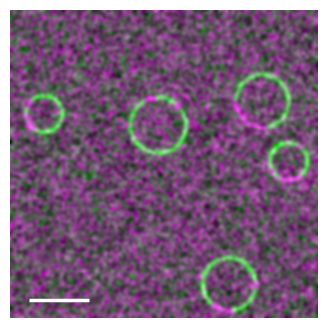

In [11]:
px_per_um = 1.0 / (RESOLUTION * 1e6)   # RESOLUTION is in meters/px
SCALE_BAR_UM = 10.0
scale_bar_px = SCALE_BAR_UM * px_per_um

composite = np.zeros((green_image.shape[0], green_image.shape[1], 3), dtype=np.float32)
composite[..., 1] = green_image.squeeze()            # green channel <- ch0
composite[..., 0] = red_image.squeeze()              # magenta = red + blue <- ch1
composite[..., 2] = red_image.squeeze()

fig, ax = plt.subplots(1, 1, figsize=(4, 4))
ax.imshow(composite)
x0, y0 = TILE_SIZE * 0.06, TILE_SIZE * 0.94
ax.plot([x0, x0 + scale_bar_px], [y0, y0], color="white", linewidth=2.5,
        solid_capstyle="butt")
ax.axis("off")
plt.show()
fig.savefig("fig1e_GUVs_sim.svg", format="svg", bbox_inches="tight", pad_inches=0, transparent=True)


## 5. Plotting the Ground Truth

The corresponding ground-truth phase masks: green where only the Lo channel's mask is set, magenta where only the Ld channel's mask is set.


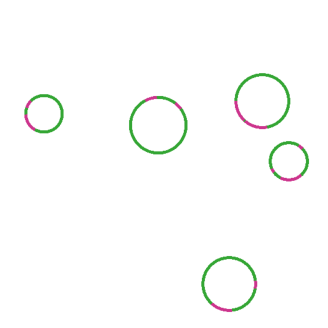

In [12]:
COLOR_CH0 = [0.20, 0.65, 0.20]  # green, ch0-only
COLOR_CH1 = [0.80, 0.20, 0.55]  # magenta, ch1-only

composite_gt = np.ones((green_mask.shape[0], green_mask.shape[1], 3), dtype=np.float32)
composite_gt[green_mask.squeeze() > 0.5] = COLOR_CH0
composite_gt[red_mask.squeeze() > 0.5] = COLOR_CH1

fig, ax = plt.subplots(1, 1, figsize=(4, 4))
ax.imshow(composite_gt)
ax.axis("off")
plt.show()

fig.savefig("fig1e_GUVs_gt.svg", format="svg", bbox_inches="tight", pad_inches=0, transparent=True)
